In [1]:
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

df = pd.read_csv("spam_dataset.csv")

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    return text

df["email_text"] = df["email_text"].apply(clean_text)

X = df["email_text"]
y = df["label"]

vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
max_features=10000
)


In [2]:
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)

model = LogisticRegression(
    C=0.5,
    max_iter=1000,
    class_weight='balanced'
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("===== METRICS =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\n===== CONFUSION MATRIX =====")
print(cm)

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

===== METRICS =====
Accuracy : 0.9820627802690582
Precision: 0.9448275862068966
Recall   : 0.9194630872483222
F1 Score : 0.9319727891156463

===== CONFUSION MATRIX =====
[[958   8]
 [ 12 137]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.94      0.92      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115




===== TOP SPAM WORDS =====
          word    weight
8891       txt  3.633964
3231      free  3.481290
5427    mobile  3.235475
1879     claim  3.017883
9795       www  2.999910
8956        uk  2.878777
8451      text  2.770213
7241     reply  2.763489
8148      stop  2.686635
567         50  2.425045
302       150p  2.308308
5889       new  2.307684
7673   service  2.216398
1986       com  2.126711
9619       won  2.103060
6716     prize  2.100974
9530       win  1.975010
1731      cash  1.910910
2281  customer  1.837942
338         18  1.825226

===== TOP HAM WORDS =====
       word    weight
6091     ok -1.953150
4847     ll -1.702023
1999   come -1.475170
5054     lt -1.368423
2305     da -1.363976
4008   home -1.359135
3685     gt -1.358939
3586    got -1.330528
7987  sorry -1.277078
4936    lor -1.205131
5056  lt gt -1.189958
4634  later -1.183241
6071     oh -1.105644
3506  going -1.093912
3540   good -1.073468
4982   love -0.997485
9413    way -0.985761
2637  doing -0.975869
98

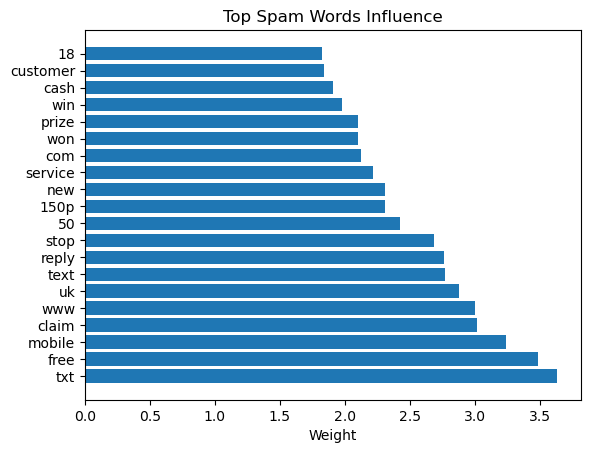

In [3]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

features_df = pd.DataFrame({
    "word": feature_names,
    "weight": coefficients
})

top_spam = features_df.sort_values(by="weight", ascending=False).head(20)

print("\n===== TOP SPAM WORDS =====")
print(top_spam)

top_ham = features_df.sort_values(by="weight", ascending=True).head(20)

print("\n===== TOP HAM WORDS =====")
print(top_ham)

import matplotlib.pyplot as plt

plt.figure()
plt.barh(top_spam["word"], top_spam["weight"])
plt.title("Top Spam Words Influence")
plt.xlabel("Weight")
plt.show()

In [4]:
df_test = pd.DataFrame(X_test.toarray())

df_test["actual"] = y_test.values
df_test["predicted"] = y_pred

wrong = df_test[df_test["actual"] != df_test["predicted"]]

print("\n===== MODEL ERROR ANALYSIS =====")

print(f"\nThe model made {len(wrong)} wrong predictions.")




===== MODEL ERROR ANALYSIS =====

The model made 20 wrong predictions.


In [5]:
print("\nSample mistakes:\n")

for i in range(min(5, len(wrong))):

    actual = wrong.iloc[i]["actual"]
    predicted = wrong.iloc[i]["predicted"]

    actual_label = "Spam" if actual == 1 else "Not Spam"
    predicted_label = "Spam" if predicted == 1 else "Not Spam"

    print(f"Example {i+1}:")
    print(f"Actual message type    : {actual_label}")
    print(f"Predicted by the model : {predicted_label}")

    if actual != predicted:
        print("The model classified this email incorrectly.\n")



Sample mistakes:

Example 1:
Actual message type    : Not Spam
Predicted by the model : Spam
The model classified this email incorrectly.

Example 2:
Actual message type    : Not Spam
Predicted by the model : Spam
The model classified this email incorrectly.

Example 3:
Actual message type    : Not Spam
Predicted by the model : Spam
The model classified this email incorrectly.

Example 4:
Actual message type    : Spam
Predicted by the model : Not Spam
The model classified this email incorrectly.

Example 5:
Actual message type    : Not Spam
Predicted by the model : Spam
The model classified this email incorrectly.



In [6]:
def explain_email(text):
    cleaned = text.lower()

    vec = vectorizer.transform([cleaned])
    prediction = model.predict(vec)[0]

    words = cleaned.split()
    impact = []

    for w in words:
        if w in vectorizer.vocabulary_:
            idx = vectorizer.vocabulary_[w]
            score = model.coef_[0][idx]
            impact.append((w, score))

    impact = sorted(impact, key=lambda x: abs(x[1]), reverse=True)

    print("\nPrediction:", "Spam" if prediction == 1 else "Not Spam")

    print("\nExplanation:")

    for word, score in impact[:5]:

        if score > 1:
            meaning = "strongly indicates spam"

        elif score > 0:
            meaning = "slightly indicates spam"

        elif score < -1:
            meaning = "strongly indicates not spam"

        else:
            meaning = "slightly indicates not spam"

        print(f"The word '{word}' {meaning}.")
explain_email("Congratulations you won a free prize click now")


Prediction: Spam

Explanation:
The word 'free' strongly indicates spam.
The word 'won' strongly indicates spam.
The word 'prize' strongly indicates spam.
The word 'congratulations' slightly indicates spam.
The word 'click' slightly indicates spam.


In [ ]:
def predict_email():
    while True:
        text = input("\n✉️ Enter email text (or type 'exit'): ")

        if text.lower() == "exit":
            break

        clean = clean_text(text)

        vec = vectorizer.transform([clean])

        prediction = model.predict(vec)[0]

        print("\n===== RESULT =====")
        if prediction == 1:
            print("🚨 Spam Email")
        else:
            print("✅ Not Spam Email")

predict_email()